In [ ]:
!pip install pandas numpy scipy scikit-learn matplotlib seaborn shap

In [ ]:
import pandas as pd

# Substitua 'data.csv' pelo nome exato do arquivo que você baixou
df = pd.read_csv('data.csv') 

# Mostra as 5 primeiras linhas da tabela
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
# 1. Limpeza: Removendo a coluna de ID e a coluna vazia do Kaggle
# Usamos errors='ignore' para não dar erro caso a coluna já tenha sido removida
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print("Formato dos dados após a limpeza:", df.shape)

# 2. Estatísticas Descritivas (Média, Desvio Padrão, Mínimo e Máximo)
# Isso é fundamental para o seu relatório técnico!
display(df.describe())

Formato dos dados após a limpeza: (569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


--- Estatísticas Descritivas do Dataset ---


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


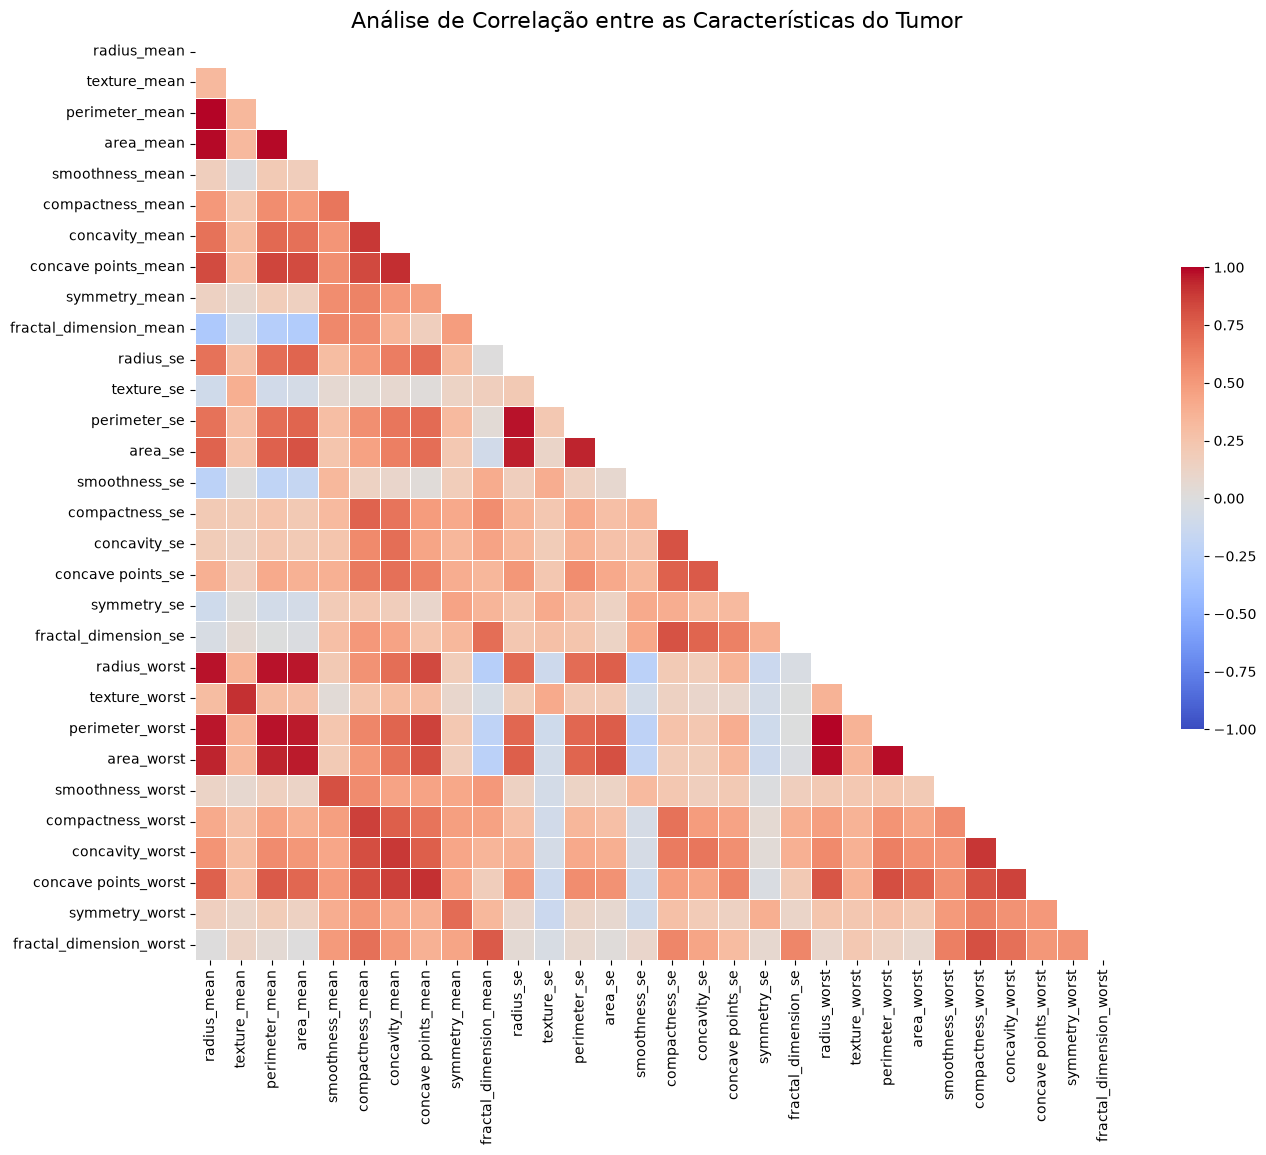

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. ESTATÍSTICAS DESCRITIVAS OBRIGATÓRIAS
print("--- Estatísticas Descritivas do Dataset ---")
display(df.describe())

# 2. ANÁLISE DE CORRELAÇÃO OBRIGATÓRIA
# Calculando a matriz de correlação (apenas para as variáveis numéricas originais)
corr_matrix = X.corr()

# Criando uma máscara para esconder a metade de cima do gráfico (que é repetida)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
plt.title("Análise de Correlação entre as Características do Tumor", fontsize=16)

# Gerando o Mapa de Calor (Heatmap) com um visual limpo e profissional
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

# Salvando a imagem para você colocar no PDF
plt.savefig('matriz_correlacao.png', bbox_inches='tight', dpi=300)
plt.show()

Matplotlib is building the font cache; this may take a moment.


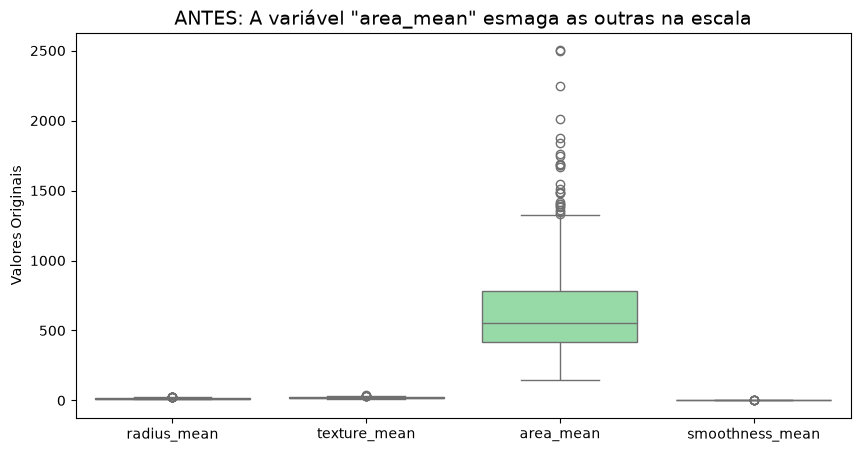

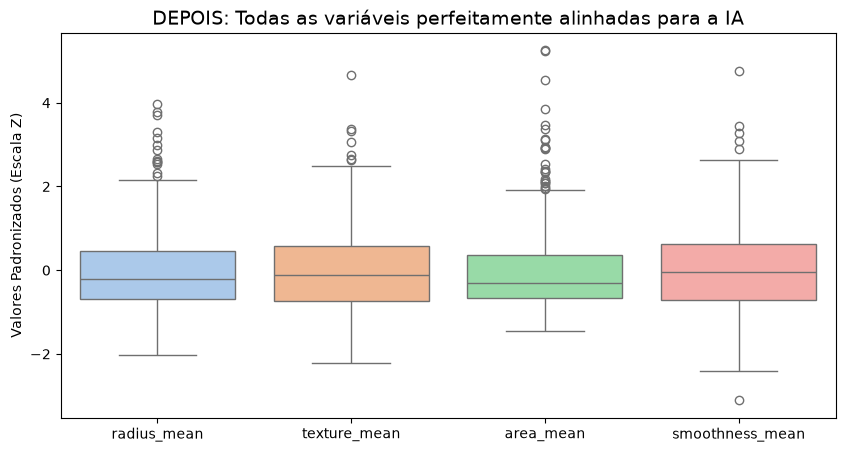

In [3]:
# Importando as bibliotecas gráficas e o StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Selecionando algumas colunas extremas para o nosso exemplo visual
colunas_exemplo = ['radius_mean', 'texture_mean', 'area_mean', 'smoothness_mean']

# ---------------------------------------------------------
# 1. O GRÁFICO "ERRADO" (Antes da Padronização)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[colunas_exemplo], palette='pastel')
plt.title('ANTES: A variável "area_mean" esmaga as outras na escala', fontsize=14)
plt.ylabel('Valores Originais')
plt.show()

# ---------------------------------------------------------
# 2. APLICANDO O PIPELINE DE PRÉ-PROCESSAMENTO (O "Certo")
# ---------------------------------------------------------
# O StandardScaler transforma os dados para terem média 0 e desvio padrão 1
scaler = StandardScaler()

# Criamos uma cópia para o gráfico, mantendo o dataset original seguro
df_exemplo_scaled = df.copy()
df_exemplo_scaled[colunas_exemplo] = scaler.fit_transform(df[colunas_exemplo])

# ---------------------------------------------------------
# 3. O GRÁFICO "CERTO" (Depois da Padronização)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_exemplo_scaled[colunas_exemplo], palette='pastel')
plt.title('DEPOIS: Todas as variáveis perfeitamente alinhadas para a IA', fontsize=14)
plt.ylabel('Valores Padronizados (Escala Z)')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# 1. Separar o que é Característica (X) do que é a Resposta/Alvo (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# 2. Separação de Treino e Teste (80% para treinar, 20% para testar)
# O "stratify=y" é o pulo do gato: ele garante que a mesma proporção 
# de Benignos e Malignos vá para o teste, evitando resultados mentirosos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Separação Concluída ---")
print(f"Pacientes para Treino da IA: {X_train.shape[0]}")
print(f"Pacientes para Teste Cego: {X_test.shape[0]}\n")

# 3. Aplicando o StandardScaler de forma correta (Pipeline de Pré-processamento)
scaler_oficial = StandardScaler()

# O "fit_transform" aprende a média/escala SOMENTE com os dados de Treino
X_train_scaled = scaler_oficial.fit_transform(X_train)

# O "transform" apenas aplica a régua no Teste, sem vazar informações
X_test_scaled = scaler_oficial.transform(X_test)

print("Padronização (Scaling) aplicada com sucesso em todas as colunas!")

--- Separação Concluída ---
Pacientes para Treino da IA: 455
Pacientes para Teste Cego: 114

Padronização (Scaling) aplicada com sucesso em todas as colunas!


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score

# 1. Recarregando e Limpando do Zero para evitar fantasmas na memória
df = pd.read_csv('data.csv')
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# 2. Conversão Segura (Garantindo que são números inteiros)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# 3. Separação do Alvo (y) e Características (X)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# 4. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Pipeline de Pré-processamento (Padronização)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Treinamento da Inteligência Artificial (Regressão Logística)
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# 7. Teste Cego e Cálculo das Métricas
y_pred_lr = modelo_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("--- Desempenho do Modelo: Regressão Logística ---")
print(f"Acurácia (Accuracy): {acc_lr:.4f} (Taxa de acerto geral)")
print(f"Recall (Sensibilidade): {rec_lr:.4f} (Dos tumores malignos, quantos a IA detectou)")
print(f"F1-score: {f1_lr:.4f} (Média entre precisão e recall)")

--- Desempenho do Modelo: Regressão Logística ---
Acurácia (Accuracy): 0.9649 (Taxa de acerto geral)
Recall (Sensibilidade): 0.9286 (Dos tumores malignos, quantos a IA detectou)
F1-score: 0.9512 (Média entre precisão e recall)


In [10]:
from sklearn.ensemble import RandomForestClassifier

# 1. Criando o segundo modelo (Random Forest)
modelo_rf = RandomForestClassifier(random_state=42)

# 2. Treinando a IA com os mesmos dados padronizados
modelo_rf.fit(X_train_scaled, y_train)

# 3. Teste Cego com os 114 pacientes inéditos
y_pred_rf = modelo_rf.predict(X_test_scaled)

# 4. Calculando as notas do Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("--- Desempenho do Modelo 2: Random Forest (Floresta Aleatória) ---")
print(f"Acurácia (Accuracy): {acc_rf:.4f}")
print(f"Recall (Sensibilidade): {rec_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

--- Desempenho do Modelo 2: Random Forest (Floresta Aleatória) ---
Acurácia (Accuracy): 0.9737
Recall (Sensibilidade): 0.9286
F1-score: 0.9630


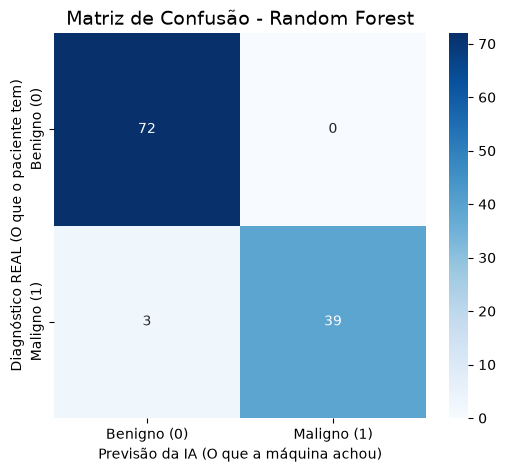

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gerando a matriz de erros e acertos para o Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
# Criando um mapa de calor visual
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benigno (0)', 'Maligno (1)'], 
            yticklabels=['Benigno (0)', 'Maligno (1)'])

plt.title('Matriz de Confusão - Random Forest', fontsize=14)
plt.ylabel('Diagnóstico REAL (O que o paciente tem)')
plt.xlabel('Previsão da IA (O que a máquina achou)')
plt.show()

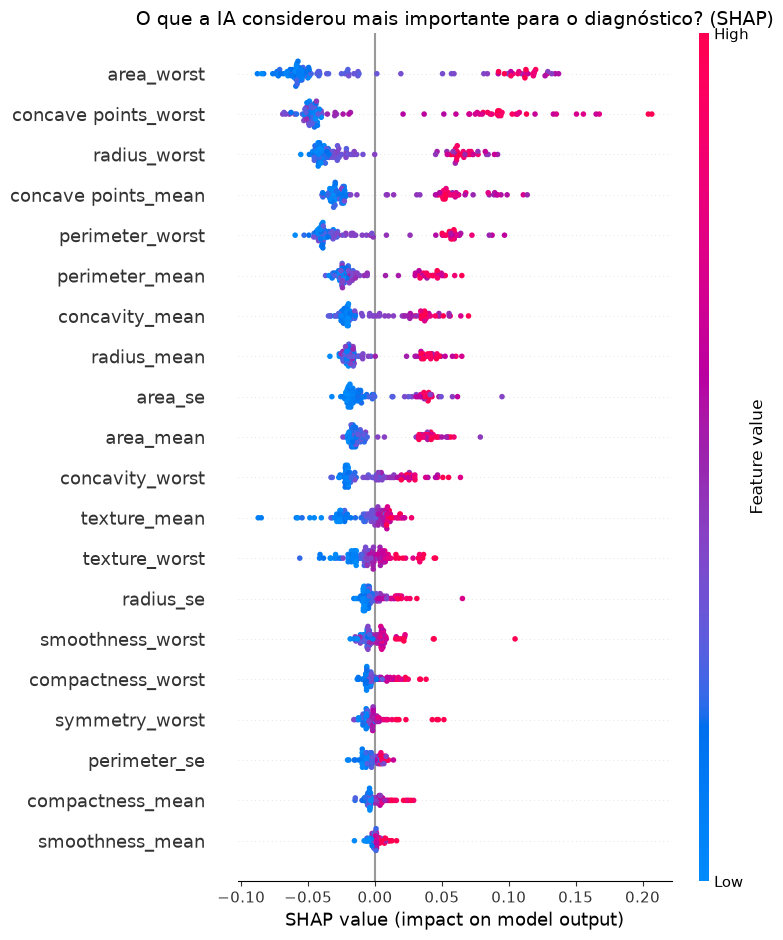

In [15]:
import shap
import matplotlib.pyplot as plt

# 1. Cria o "explicador" do SHAP para ler o cérebro do nosso Random Forest
explainer = shap.TreeExplainer(modelo_rf)

# 2. Calcula o peso de cada variável usando os dados do teste cego
shap_values = explainer.shap_values(X_test_scaled)

# 3. Tratamento robusto para pegar a classe 1 (Maligno) 
# Funciona tanto nas versões antigas quanto nas novas do pacote
valores_maligno = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# 4. Gera o Gráfico (Summary Plot)
plt.figure(figsize=(8, 6))
plt.title('O que a IA considerou mais importante para o diagnóstico? (SHAP)', fontsize=14)
shap.summary_plot(valores_maligno, X_test_scaled, feature_names=X.columns)